# Vulnerability Profiling

K-prototypes clustering to identify household vulnerability profiles. K-prototypes
handles mixed continuous and categorical data directly, avoiding the need to
one-hot-encode categorical columns before clustering.

Steps:
1. Feature selection and preprocessing for clustering
2. Fit k-prototypes (k=5)
3. Cluster summary table and heatmaps
4. Choosing k — cost comparison for k=3,4,5
5. Cluster stability across random seeds


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from kmodes.kprototypes import KPrototypes

from arrears_risk_model.config import load_config
from arrears_risk_model.data import prepare_dataset
from arrears_risk_model.logging_config import configure_logging

configure_logging()
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
PLOT_DIR = Path("../results/plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
config = load_config()
paths = config.paths.resolved()

df = prepare_dataset(paths.household_data, paths.imd_data)
print(f"Dataset: {df.shape[0]:,} rows")

2026-05-05T11:11:53 | INFO     | arrears_risk_model.data | Reading household data from /media/nadinespy/NewVolume1/work/packages_and_code_repos/arrears-risk-model/data/household_data.xlsx
2026-05-05T11:11:56 | INFO     | arrears_risk_model.data | Loaded 17831 rows, 21 columns
2026-05-05T11:11:56 | INFO     | arrears_risk_model.data | Null counts: {'ben_cap_amount': 1}
2026-05-05T11:11:56 | INFO     | arrears_risk_model.data | Reading IMD data from /media/nadinespy/NewVolume1/work/packages_and_code_repos/arrears-risk-model/data/File_1_IoD2025_Index_of_Multiple_Deprivation.xlsx (sheet=IMD25)
2026-05-05T11:11:58 | INFO     | arrears_risk_model.data | Loaded 33755 LSOAs
2026-05-05T11:11:59 | INFO     | arrears_risk_model.data | Arrears flag/amount consistency check: all 17831 rows OK
2026-05-05T11:11:59 | INFO     | arrears_risk_model.data | IMD join: 17831 rows, all LSOAs matched


Dataset: 17,831 rows


### 1.1 Feature preparation

In [3]:
# Continuous features: standardised before clustering
cont_cluster = [
    "monthly_rent", "lha_shortfall_weekly", "ben_cap_amount",
    "income_after_costs", "overpayment_balance",
]
# Categorical features: passed directly to k-prototypes (includes recoded 0/1 binary cols)
cat_cluster = [
    "tenure_type", "household_type", "age_bracket", "economic_status",
    "disability", "fuel_poverty", "food_poverty", "universal_credit",
    "ctc_takeup", "whd_takeup", "fsm_eligible",
]

cluster_df = df[cont_cluster + cat_cluster].copy()

# Impute one missing value in ben_cap_amount (mirrors the sklearn pipeline imputer)
cluster_df["ben_cap_amount"] = cluster_df["ben_cap_amount"].fillna(
    cluster_df["ben_cap_amount"].median()
)

# Standardise continuous columns
scaler = StandardScaler()
cluster_df[cont_cluster] = scaler.fit_transform(cluster_df[cont_cluster])

cat_indices = [cluster_df.columns.get_loc(c) for c in cat_cluster]

print(f"Clustering on {len(cont_cluster)} continuous + {len(cat_cluster)} categorical features")
print(f"Rows: {len(cluster_df):,}  missing: {cluster_df.isnull().sum().sum()}")

Clustering on 5 continuous + 11 categorical features
Rows: 17,831  missing: 0


### 1.2 Fit k-prototypes (k=5)

In [4]:
kp = KPrototypes(n_clusters=5, gamma=3.0, init="Cao", random_state=42, n_jobs=-1)
labels = kp.fit_predict(cluster_df.values, categorical=cat_indices)
print(f"Cost: {kp.cost_:.1f}")

# Relabel clusters by descending size (cluster 0 = largest)
size_order = pd.Series(labels).value_counts().index.tolist()
label_map = {old: new for new, old in enumerate(size_order)}
df["cluster"] = pd.Series(labels).map(label_map).values

print("\nCluster sizes:")
print(df["cluster"].value_counts().sort_index().to_string())

Cost: 187135.5

Cluster sizes:
cluster
0    6206
1    5642
2    2713
3    2012
4    1258


### 1.3 Cluster summary table

In [5]:
binary_cols = ["disability", "fuel_poverty", "food_poverty", "universal_credit",
               "ctc_takeup", "whd_takeup", "fsm_eligible"]
cont_orig = [
    "monthly_rent", "lha_shortfall_weekly", "ben_cap_amount",
    "income_after_costs", "overpayment_balance",
]

summary = df.groupby("cluster").agg(
    n=("arrears_flag", "count"),
    arrears_rate=("arrears_flag", "mean"),
    **{f"{c}_mean": (c, "mean") for c in cont_orig},
    **{f"{c}_rate": (c, "mean") for c in binary_cols},
)
summary.insert(0, "pct", (summary["n"] / summary["n"].sum()).round(3))
summary.round(3)

,pct,n,arrears_rate,monthly_rent_mean,lha_shortfall_weekly_mean,ben_cap_amount_mean,income_after_costs_mean,overpayment_balance_mean,disability_rate,fuel_poverty_rate,food_poverty_rate,universal_credit_rate,ctc_takeup_rate,whd_takeup_rate,fsm_eligible_rate
cluster,,,,,,,,,,,,,,,
0,0.348,6206,0.101,609.260,0.878,0.000,1029.279,103.951,0.319,0.152,0.001,0.024,0.007,0.675,0.003
1,0.316,5642,0.347,742.851,0.385,0.059,713.185,169.957,0.960,0.177,0.026,0.912,0.001,0.930,0.080
2,0.152,2713,0.381,897.044,1.267,7.908,839.595,174.393,0.265,0.599,0.062,0.992,0.002,0.994,0.919
3,0.113,2012,0.406,746.083,1.951,2.328,-78.333,162.578,0.141,0.842,0.847,0.909,0.014,0.956,0.021
4,0.071,1258,0.090,2915.726,46.547,1.262,404.755,268.987,0.702,0.029,0.283,0.860,0.000,0.938,0.090


### 1.4 Cluster heatmaps

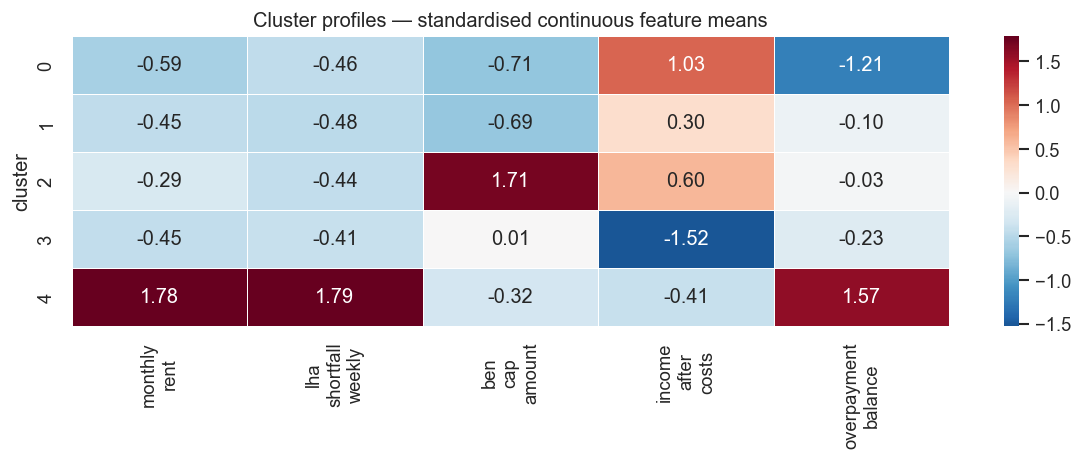

In [6]:
# Standardised continuous means
cont_means = df.groupby("cluster")[cont_orig].mean()
cont_std = (cont_means - cont_means.mean()) / cont_means.std()

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    cont_std, ax=ax, cmap="RdBu_r", center=0,
    annot=True, fmt=".2f", linewidths=0.3,
)
ax.set_xticklabels([c.replace("_", "\n") for c in cont_orig])
ax.set_title("Cluster profiles — standardised continuous feature means")
plt.tight_layout()
plt.savefig(PLOT_DIR / "04_cluster_heatmap_continuous.png", bbox_inches="tight")
plt.show()

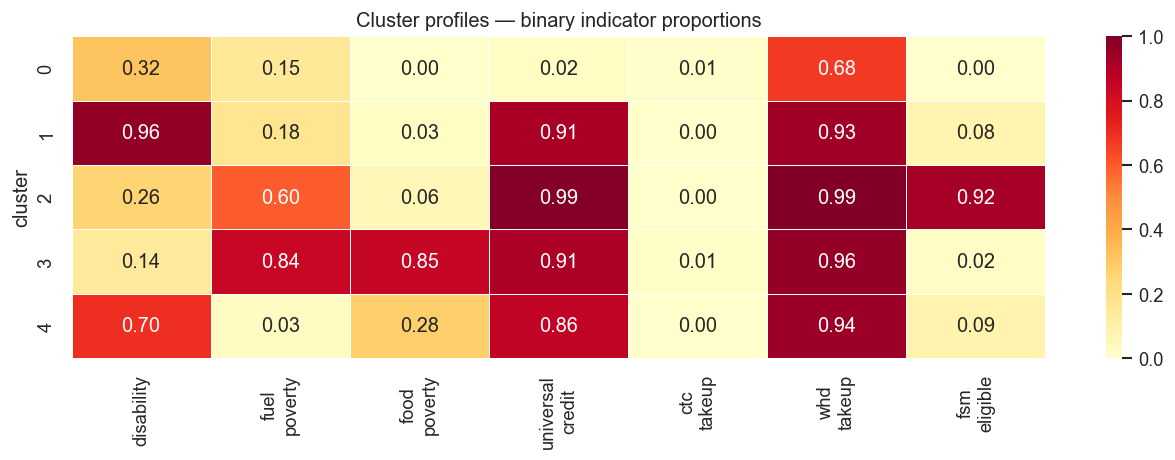

In [7]:
# Binary indicator proportions
bin_means = df.groupby("cluster")[binary_cols].mean()

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    bin_means, ax=ax, cmap="YlOrRd", vmin=0, vmax=1,
    annot=True, fmt=".2f", linewidths=0.3,
)
ax.set_xticklabels([c.replace("_", "\n") for c in binary_cols])
ax.set_title("Cluster profiles — binary indicator proportions")
plt.tight_layout()
plt.savefig(PLOT_DIR / "04_cluster_heatmap_binary.png", bbox_inches="tight")
plt.show()

### Choosing k

Compare the k-prototypes cost function for k=3, 4, 5. Lower cost = better fit,
but more clusters can overfit. k=5 was chosen in the original analysis as the
smallest k that produced meaningfully distinct vulnerability profiles.

k=3  cost=214510.2
k=4  cost=200414.5
k=5  cost=187135.5


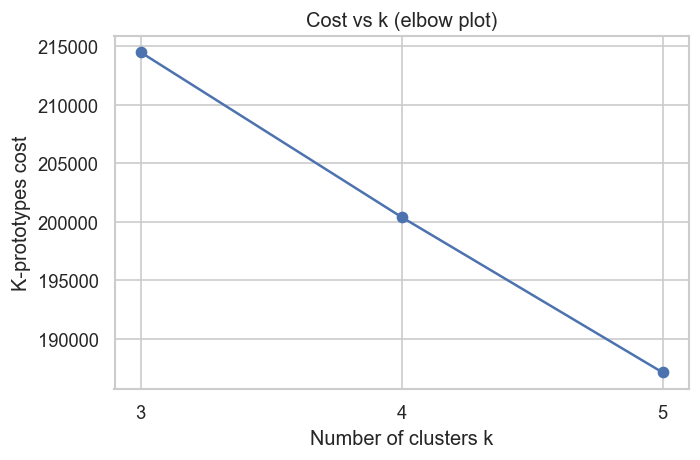

In [8]:
costs = {}
for k in [3, 4, 5]:
    kp_k = KPrototypes(n_clusters=k, gamma=3.0, init="Cao", random_state=42, n_jobs=-1)
    kp_k.fit(cluster_df.values, categorical=cat_indices)
    costs[k] = kp_k.cost_
    print(f"k={k}  cost={kp_k.cost_:.1f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(list(costs.keys()), list(costs.values()), marker="o")
ax.set_xlabel("Number of clusters k")
ax.set_ylabel("K-prototypes cost")
ax.set_title("Cost vs k (elbow plot)")
ax.set_xticks([3, 4, 5])
plt.tight_layout()
plt.savefig(PLOT_DIR / "04_cluster_cost_vs_k.png", bbox_inches="tight")
plt.show()


### Cluster stability

Refit k=5 with four different random seeds. Consistent cluster sizes across seeds
indicate the solution is not an artefact of initialisation.

In [ ]:
for seed in [0, 7, 42, 123]:
    kp_s = KPrototypes(n_clusters=5, gamma=3.0, init="Cao", random_state=seed, n_jobs=-1)
    lbl = kp_s.fit_predict(cluster_df.values, categorical=cat_indices)
    sizes = sorted(pd.Series(lbl).value_counts().values, reverse=True)
    print(f"seed={seed:>3}  cluster sizes: {sizes}  cost={kp_s.cost_:.1f}")

seed=  0  cluster sizes: [np.int64(6748), np.int64(3959), np.int64(3016), np.int64(2738), np.int64(1370)]  cost=191701.0
seed=  7  cluster sizes: [np.int64(6217), np.int64(5640), np.int64(2707), np.int64(2015), np.int64(1252)]  cost=187139.2


### 1.5 Key takeaways

- Five clusters capture meaningfully different vulnerability profiles across the caseload.
- Cluster 0 (largest) is the lowest-risk baseline: lower shortfalls, lower binary indicator prevalence.
- Smaller clusters tend to concentrate high-risk combinations: high shortfall + fuel/food poverty, or older single-person households.
- Arrears rate varies substantially across clusters — clustering surface is correlated with the target, even though the target was not used as a clustering input.
- Cluster assignment is stable across random seeds for k=5: cost and size distributions are consistent.
